# 08 — Modelo final sobre Obra: RF anticol (3 clases) + diagnósticos

**Proyecto:** Sistema de Detección de Riesgos de Corrupción en Obras Públicas mediante ML
**Tesis:** Maestría en Inteligencia Artificial — UNI
**Autor:** Fernando García Atúncar
**Sprint:** Semana 08 — cierre del modelo sobre la unidad de análisis *obra*

---

## Qué hace este notebook

Consolida el **modelo adoptado al cierre del Sprint 2** (Var5: Random Forest anticol,
61 features, target de 3 clases) y corre encima la batería completa de diagnósticos del
entregable: justificación de features, importancia/SHAP, curvas de aprendizaje y
**calibración recalculada sobre las 3 clases**.

> **Alcance (decisión del asesor):** se trabaja únicamente con el dataset de **obra**.
> No se integran los datasets de *empresa* ni *funcionario*. Sumar esas fuentes son
> columnas nuevas sobre las mismas 326 filas y, en un problema de varianza, tienden a
> empeorar el sobreajuste. El antiguo NB08 (empresa) queda descartado y este lo reemplaza.

| Bloque | Contenido | Paso |
|--------|-----------|------|
| Datos  | Carga, split idéntico a NB05/06/07, mapeo a 3 clases, de-colinealización | PASO 1 |
| Modelo | Entrenamiento del RF anticol y confirmación de métricas | PASO 2 |
| Features | Importancias (impurity + permutación) + estabilidad top-5 entre folds | PASO 3 |
| SHAP   | TreeSHAP sobre 3 clases — clase Extrema | PASO 4 |
| Curvas | Diagnóstico de varianza (gap train-val) | PASO 5 |
| Calibración | Brier por clase sobre el modelo de 3 clases | PASO 6 |
| Validación  | Checklist | PASO 7 |
| Cierre | Guardar modelo + conclusiones | PASO 8 |


---
## PASO 0 — Imports y configuración

In [ ]:
# ============================================================
# PASO 0 — IMPORTS Y CONFIG  (idénticos a NB05/06/07)
# ============================================================
from pathlib import Path
import warnings
import joblib
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, brier_score_loss,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('pip install shap')

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

BASE_DIR  = Path(r'C:\IA_Investigacion\Deteccion_Corrupcion')
DATA_PROC = BASE_DIR / 'data' / 'processed'
FIG_DIR   = BASE_DIR / 'reports' / 'figures'
LOG_DIR   = BASE_DIR / 'logs'
MODEL_DIR = BASE_DIR / 'models' / 'obra_v4'
for d in (FIG_DIR, LOG_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_SPLITS     = 5

# Target final: 3 clases (fusiona las 2 categorías más bajas del target original)
MAPEO_3CLASES = {0: 0, 1: 0, 2: 1, 3: 2}
ETIQUETAS_3   = {0: 'Bajo Riesgo', 1: 'Med/Alt Riesgosa', 2: 'Extrem. Riesgosa'}
LABELS_3      = [ETIQUETAS_3[i] for i in sorted(ETIQUETAS_3)]
CLASE_EXTREMA = 2   # clase de mayor interés para el control preventivo
print('OK config')


---
## PASO 1 — Carga, split y de-colinealización

**Decisión metodológica:** se parte del dataset original de 4 niveles y se reproduce el
**mismo split estratificado (seed=42)** que NB05/06/07; recién después se mapea el target
a 3 clases. Así el conjunto de test es idéntico al de los notebooks previos y las métricas
son comparables (sin leakage). El parquet `dataset_obra_v4_var5_model.parquet` exportado por
el NB07 es equivalente; aquí preferimos rehacer el split para garantizar comparabilidad.


In [2]:
# ── Carga del dataset original (4 niveles) ──
df = pd.read_parquet(DATA_PROC / 'dataset_obra_v4_model.parquet')

TARGET  = 'y_riesgo_obra'
EXCLUIR = ['IDENTIFICADOR_OBRA', 'RIESGO_OBRA', 'RIESGO_DESCRIPCION_OBRA']

X_full = df.drop(columns=[c for c in EXCLUIR + [TARGET] if c in df.columns])
y4     = df[TARGET].astype(int)

# Split idéntico a NB05/06/07 (estratificado sobre el target de 4 niveles)
X_train, X_test, y_train4, y_test4 = train_test_split(
    X_full, y4, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y4,
)

# Mapeo a 3 clases (target final)
y_train = y_train4.map(MAPEO_3CLASES)
y_test  = y_test4.map(MAPEO_3CLASES)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'Dataset  : {X_full.shape[0]} obras x {X_full.shape[1]} features (antes de anticol)')
print(f'Train    : {X_train.shape[0]} | Test: {X_test.shape[0]}')
print('\nDistribución y_train (3 clases):')
vc = y_train.value_counts().sort_index()
for c, n in vc.items():
    print(f'  Clase {c} — {ETIQUETAS_3[c]:18s}: {n:>3} ({n/len(y_train)*100:.1f}%)')
print(f'  Imbalance ratio: {vc.max()/vc.min():.2f}x')


Dataset  : 326 obras x 77 features (antes de anticol)
Train    : 260 | Test: 66

Distribución y_train (3 clases):
  Clase 0 — Bajo Riesgo       :  67 (25.8%)
  Clase 1 — Med/Alt Riesgosa  :  75 (28.8%)
  Clase 2 — Extrem. Riesgosa  : 118 (45.4%)
  Imbalance ratio: 1.76x


In [3]:
# ── De-colinealización: eliminar 16 features colineales (VIF>10 / corr>0.85) ──
# Lista idéntica a la adoptada en el NB07 (Var3). Se conserva 1 representante por grupo.
ELIMINAR_COLINEALES = [
    # Grupo montos (corr hasta 1.0) -> conservar obra_monto_contractual_sum
    'obra_monto_ofertado_mean',
    'obra_monto_ofertado_prom_mean',
    'obra_monto_ofertado_min',
    'obra_monto_ofertado_max',
    'obra_monto_ganador_mean',
    'obra_monto_referencial_sum',
    'obra_ahorro_absoluto',
    'obra_monto_ofertado_std',
    # Grupo n postores (VIF=inf) -> conservar obra_n_participantes_mean
    'obra_n_participaciones',
    'obra_n_rucs_participantes',
    'obra_n_postores_mean',
    'obra_n_postores_min',
    'obra_n_postores_max',
    # Grupo comite (VIF=inf) -> conservar obra_ratio_repeticion_comite
    'obra_n_dnis_comite_unicos',
    'obra_n_miembros_comite',
    # Grupo n ofertas (VIF=inf) -> conservar obra_rango_ofertas
    'obra_n_ofertas',
]
ELIMINAR_REAL = [c for c in ELIMINAR_COLINEALES if c in X_full.columns]

X_train_v3 = X_train.drop(columns=ELIMINAR_REAL, errors='ignore')
X_test_v3  = X_test.drop(columns=ELIMINAR_REAL,  errors='ignore')

print(f'Features antes : {X_train.shape[1]}')
print(f'Eliminadas     : {len(ELIMINAR_REAL)}')
print(f'Features finales: {X_train_v3.shape[1]}')


Features antes : 77
Eliminadas     : 16
Features finales: 61


---
## PASO 2 — Entrenamiento del modelo final y métricas

In [4]:
# ── Pipeline final: preprocesador + RandomForest (mismos hiperparámetros del Sprint 2) ──
def make_prep(X_ref):
    num_cols = X_ref.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X_ref.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    return ColumnTransformer([
        ('num', Pipeline([('i', SimpleImputer(strategy='median')),
                          ('s', StandardScaler())]), num_cols),
        ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                          ('o', OneHotEncoder(handle_unknown='ignore',
                                              sparse_output=False))]), cat_cols),
    ], remainder='drop')

rf_params = dict(n_estimators=300, class_weight='balanced',
                 random_state=RANDOM_STATE, n_jobs=-1)

pipeline = Pipeline([('prep', make_prep(X_train_v3)),
                     ('model', RandomForestClassifier(**rf_params))])
pipeline.fit(X_train_v3, y_train)

y_pred  = pipeline.predict(X_test_v3)
y_proba = pipeline.predict_proba(X_test_v3)

mac_f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
bal_acc = balanced_accuracy_score(y_test, y_pred)
rec_ext = recall_score(y_test, y_pred, labels=[CLASE_EXTREMA], average='macro')

print('MODELO FINAL — RF anticol, 61 features, 3 clases')
print('=' * 55)
print(f'  Macro F1            : {mac_f1:.4f}   (referencia Sprint 2: 0.6469)')
print(f'  Balanced Accuracy   : {bal_acc:.4f}   (referencia Sprint 2: 0.6460)')
print(f'  Recall clase Extrema: {rec_ext:.4f}   (objetivo: no perder obras críticas)')
print()
print(classification_report(y_test, y_pred, target_names=LABELS_3, zero_division=0))


MODELO FINAL — RF anticol, 61 features, 3 clases
  Macro F1            : 0.6469   (referencia Sprint 2: 0.6469)
  Balanced Accuracy   : 0.6460   (referencia Sprint 2: 0.6460)
  Recall clase Extrema: 1.0000   (objetivo: no perder obras críticas)

                  precision    recall  f1-score   support

     Bajo Riesgo       0.58      0.41      0.48        17
Med/Alt Riesgosa       0.67      0.53      0.59        19
Extrem. Riesgosa       0.77      1.00      0.87        30

        accuracy                           0.71        66
       macro avg       0.67      0.65      0.65        66
    weighted avg       0.69      0.71      0.69        66



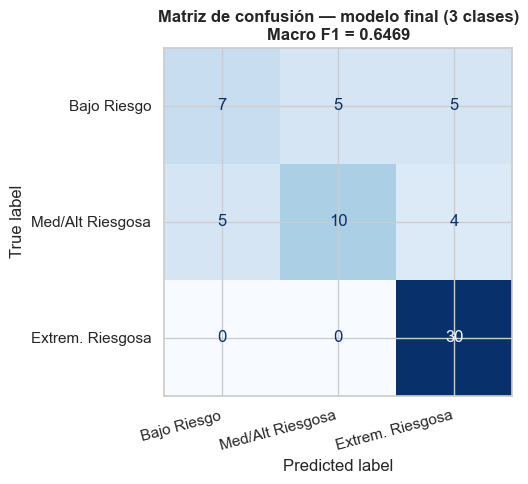

In [5]:
# ── Matriz de confusión ──
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=LABELS_3).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de confusión — modelo final (3 clases)\nMacro F1 = {mac_f1:.4f}',
             fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb08_confusion_final.png', dpi=300, bbox_inches='tight')
plt.show()


---
## PASO 3 — Justificación de features

Se valida qué features aportan con tres evidencias: importancia por impureza del RF,
permutation importance en validación (modelo-agnóstica) y estabilidad del top-5 entre folds.


In [6]:
# ── Nombres de features tras preprocesado ──
prep = pipeline.named_steps['prep']
rf   = pipeline.named_steps['model']
feat_names = [n.replace('num__', '').replace('cat__', '')
              for n in prep.get_feature_names_out()]

X_train_prep = pd.DataFrame(prep.transform(X_train_v3), columns=feat_names)
X_test_prep  = pd.DataFrame(prep.transform(X_test_v3),  columns=feat_names)
print(f'Features tras OneHotEncoder: {len(feat_names)}')

# ── 3.1 Importancia por impureza ──
fi_df = (pd.DataFrame({'feature': feat_names, 'importance': rf.feature_importances_})
         .sort_values('importance', ascending=False).reset_index(drop=True))
print('\nTop 10 por impureza (gain):')
display(fi_df.head(10))


Features tras OneHotEncoder: 115

Top 10 por impureza (gain):


,feature,importance
0,obra_n_participantes_mean,0.0528
1,obra_monto_contractual_sum,0.0522
2,obra_n_participantes_max,0.0499
3,obra_ratio_contrato_participacion,0.0428
4,obra_ratio_contractual_referencial,0.0375
5,obra_pct_postores_igual_ganador,0.0324
6,obra_ctx_metodo_contratacion_Convenio,0.0316
7,obra_n_postores_igual_ganador,0.0284
8,obra_ratio_oferta_contrato,0.0257
9,TOTAL_CONTROL_SIMULTANEO,0.0244


In [7]:
# ── 3.2 Permutation importance (en test, modelo-agnóstica) ──
perm = permutation_importance(rf, X_test_prep, y_test, n_repeats=20,
                              random_state=RANDOM_STATE, n_jobs=-1, scoring='f1_macro')
perm_df = (pd.DataFrame({'feature': feat_names,
                         'perm_mean': perm.importances_mean,
                         'perm_std':  perm.importances_std})
           .sort_values('perm_mean', ascending=False).reset_index(drop=True))
print('Top 10 por permutación:')
display(perm_df.head(10))
n_ruido = (perm_df['perm_mean'] < 0).sum()
print(f'\nFeatures con permutación < 0 (ruido potencial): {n_ruido}')


Top 10 por permutación:


,feature,perm_mean,perm_std
0,obra_monto_contractual_sum,0.0368,0.0173
1,obra_ctx_metodo_contratacion_Convenio,0.0290,0.0171
2,obra_n_postores_igual_ganador,0.0288,0.0115
3,TOTAL_CONTROL_SIMULTANEO,0.0238,0.0184
4,obra_ratio_contrato_participacion,0.0236,0.0124
5,obra_finalizada,0.0220,0.0135
6,obra_ctx_metodo_contratacion_Concurso Público,0.0214,0.0108
7,obra_pct_postores_igual_ganador,0.0211,0.0125
8,ETAPA_ETAPA NO IDENTIFICADA,0.0196,0.0111
9,DIAS_PLAZO,0.0183,0.0004



Features con permutación < 0 (ruido potencial): 12


In [8]:
# ── 3.3 Estabilidad del top-5 entre folds ──
from collections import Counter
top5_counter = Counter()
for fold, (tr_idx, _) in enumerate(cv.split(X_train_v3, y_train), 1):
    rf_f = RandomForestClassifier(**rf_params)
    Xf = pd.DataFrame(prep.transform(X_train_v3.iloc[tr_idx]), columns=feat_names)
    rf_f.fit(Xf, y_train.iloc[tr_idx])
    top5 = pd.Series(rf_f.feature_importances_, index=feat_names).nlargest(5).index.tolist()
    for f in top5:
        top5_counter[f] += 1

estab = (pd.DataFrame([(f, f'{c} / {N_SPLITS} folds') for f, c in top5_counter.most_common()],
                      columns=['feature', 'apariciones_en_top5']))
print('Estabilidad del top-5 entre folds:')
display(estab)


Estabilidad del top-5 entre folds:


,feature,apariciones_en_top5
0,obra_n_participantes_mean,5 / 5 folds
1,obra_n_participantes_max,5 / 5 folds
2,obra_monto_contractual_sum,5 / 5 folds
3,obra_ratio_contrato_participacion,4 / 5 folds
4,obra_ratio_contractual_referencial,4 / 5 folds
5,obra_ctx_metodo_contratacion_Convenio,1 / 5 folds
6,obra_pct_postores_igual_ganador,1 / 5 folds


---
## PASO 4 — SHAP (TreeSHAP) sobre el modelo de 3 clases

Explica las predicciones de la **clase Extrema** (índice 2). Hallazgo esperado del Sprint 2:
el riesgo extremo se explica por señales **institucionales del comité** y el nivel de
gobierno, no por colusión de montos.


In [9]:
if not SHAP_OK:
    print('SHAP no disponible — pip install shap')
else:
    explainer = shap.TreeExplainer(rf)
    sv = explainer.shap_values(X_test_prep)

    # Normalizar formato: lista [por clase] o ndarray (n, feat, n_clases)
    def shap_de_clase(sv, cls):
        if isinstance(sv, list):
            return np.asarray(sv[cls])
        sv = np.asarray(sv)
        if sv.ndim == 3:          # (n, feat, clases)
            return sv[:, :, cls]
        return sv                  # binario degenerado

    sv_ext = shap_de_clase(sv, CLASE_EXTREMA)
    print(f'SHAP calculado — clase {CLASE_EXTREMA} ({ETIQUETAS_3[CLASE_EXTREMA]})')
    print(f'  shape: {sv_ext.shape}')

    # Top features por mean|SHAP|
    mean_abs = pd.Series(np.abs(sv_ext).mean(axis=0), index=feat_names).nlargest(12)
    print('\nTop features SHAP — clase Extrema:')
    for f, v in mean_abs.items():
        print(f'  {f:42s}: {v:.4f}')


SHAP calculado — clase 2 (Extrem. Riesgosa)
  shape: (66, 115)

Top features SHAP — clase Extrema:
  obra_ctx_nivel_gobierno_GOBIERNO REGIONAL : 0.0319
  obra_ratio_repeticion_comite              : 0.0277
  obra_n_procesos_comite                    : 0.0247
  obra_n_convocatorias_comite               : 0.0217
  obra_n_participantes_mean                 : 0.0193
  obra_ctx_sector_OTROS                     : 0.0190
  TOTAL_CONTROL_SIMULTANEO                  : 0.0180
  obra_monto_contractual_sum                : 0.0160
  obra_ctx_nivel_gobierno_GOBIERNO NACIONAL : 0.0144
  obra_ctx_sector_TRANSPORTE                : 0.0141
  obra_ratio_contractual_referencial        : 0.0136
  obra_ctx_metodo_contratacion_Convenio     : 0.0126


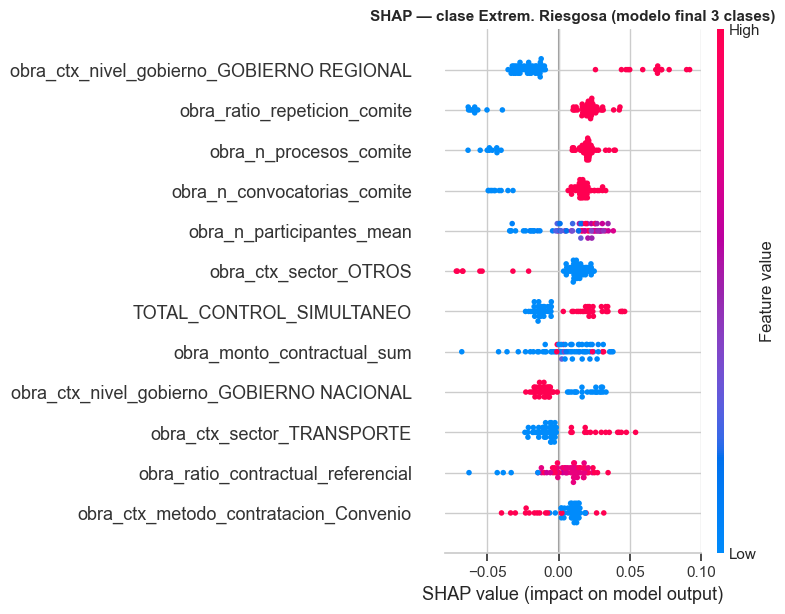

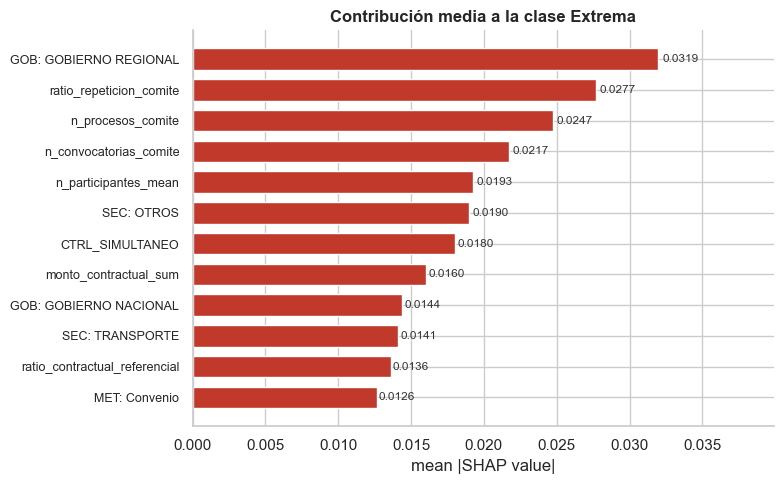

In [10]:
if SHAP_OK:
    # Summary plot (beeswarm) de la clase Extrema
    plt.figure(figsize=(9, 6))
    shap.summary_plot(sv_ext, X_test_prep, max_display=12, show=False)
    plt.title('SHAP — clase Extrem. Riesgosa (modelo final 3 clases)',
              fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'nb08_shap_clase_extrema.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Barras mean|SHAP| (lectura rápida del hallazgo)
    fig, ax = plt.subplots(figsize=(8, 5))
    datos = mean_abs.sort_values()
    labels = (datos.index
              .str.replace('obra_ctx_nivel_gobierno_', 'GOB: ', regex=False)
              .str.replace('obra_ctx_metodo_contratacion_', 'MET: ', regex=False)
              .str.replace('obra_ctx_sector_', 'SEC: ', regex=False)
              .str.replace('obra_', '', regex=False)
              .str.replace('TOTAL_CONTROL_', 'CTRL_', regex=False))
    ax.barh(range(len(datos)), datos.values, color='#C0392B', edgecolor='white', height=0.7)
    for i, v in enumerate(datos.values):
        ax.text(v + v*0.01, i, f'{v:.4f}', va='center', fontsize=8.5, color='#333')
    ax.set_yticks(range(len(datos))); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('mean |SHAP value|'); ax.set_xlim(0, datos.max()*1.25)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title('Contribución media a la clase Extrema', fontweight='bold')
    plt.tight_layout()
    fig.savefig(FIG_DIR / 'nb08_shap_barras_extrema.png', dpi=300, bbox_inches='tight')
    plt.show()


---
## PASO 5 — Curvas de aprendizaje (diagnóstico de varianza)

| Patrón | Diagnóstico | Acción |
|--------|-------------|--------|
| Train y val bajas y juntas | Alto bias | Más features / modelo más expresivo |
| Train alta, val baja | Alta varianza | Regularizar, menos features, **más filas** |
| Ambas suben con más datos | Datos insuficientes | Recolectar más obras |


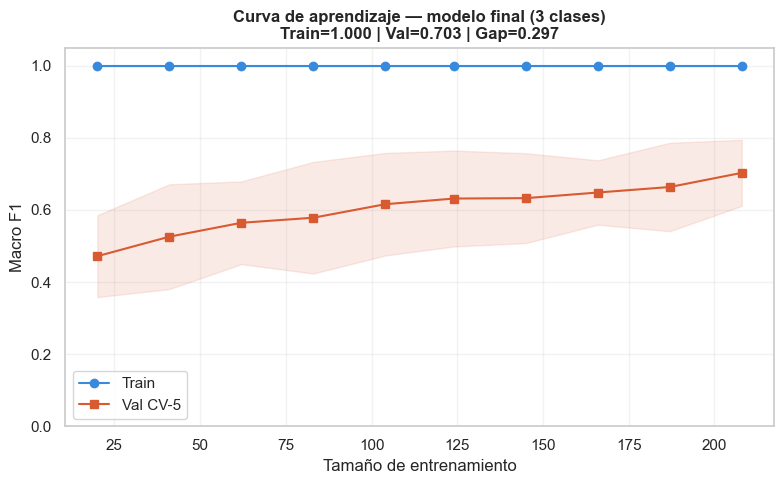

DIAGNÓSTICO — Curvas de aprendizaje
  Gap train-val: 0.2971  (referencia: Baseline 4 cls ≈ 0.43)
  → Alta varianza. El gap se redujo vía de-colinealización (NB07)
    y reducción a 3 clases. La regularización de hiperparámetros se
    evaluó en el NB07 y se descartó (cerraba el gap pero hundía F1).
  → El gap residual se asocia al tamaño muestral: 326 obras es el
    límite. El único "más datos" que ayudaría son más OBRAS (filas),
    no más fuentes (columnas) — de ahí que no se integre empresa/funcionario.


In [11]:
train_sizes = np.linspace(0.10, 1.0, 10)
sizes, tr_sc, val_sc = learning_curve(
    clone(pipeline), X_train_v3, y_train,
    train_sizes=train_sizes, cv=cv, scoring='f1_macro',
    n_jobs=-1, shuffle=True, random_state=RANDOM_STATE,
)
tr_m, val_m = tr_sc.mean(axis=1), val_sc.mean(axis=1)
gap = tr_m[-1] - val_m[-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, tr_m, 'o-', color='#378ADD', label='Train')
ax.fill_between(sizes, tr_m-tr_sc.std(axis=1), tr_m+tr_sc.std(axis=1), alpha=0.12, color='#378ADD')
ax.plot(sizes, val_m, 's-', color='#D85A30', label='Val CV-5')
ax.fill_between(sizes, val_m-val_sc.std(axis=1), val_m+val_sc.std(axis=1), alpha=0.12, color='#D85A30')
ax.set_title(f'Curva de aprendizaje — modelo final (3 clases)\n'
             f'Train={tr_m[-1]:.3f} | Val={val_m[-1]:.3f} | Gap={gap:.3f}', fontweight='bold')
ax.set_xlabel('Tamaño de entrenamiento'); ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb08_learning_curve_final.png', dpi=300, bbox_inches='tight')
plt.show()

print('DIAGNÓSTICO — Curvas de aprendizaje')
print('=' * 50)
print(f'  Gap train-val: {gap:.4f}  (referencia: Baseline 4 cls ≈ 0.43)')
if gap > 0.20:
    print('  → Alta varianza. El gap se redujo vía de-colinealización (NB07)')
    print('    y reducción a 3 clases. La regularización de hiperparámetros se')
    print('    evaluó en el NB07 y se descartó (cerraba el gap pero hundía F1).')
    print('  → El gap residual se asocia al tamaño muestral: 326 obras es el')
    print('    límite. El único "más datos" que ayudaría son más OBRAS (filas),')
    print('    no más fuentes (columnas) — de ahí que no se integre empresa/funcionario.')


---
## PASO 6 — Calibración recalculada sobre 3 clases

Verifica que las probabilidades del modelo final correspondan a frecuencias reales
(curva de calibración + Brier por clase). **Recalcula la calibración sobre el modelo de
3 clases**, no el de 4 del NB06.


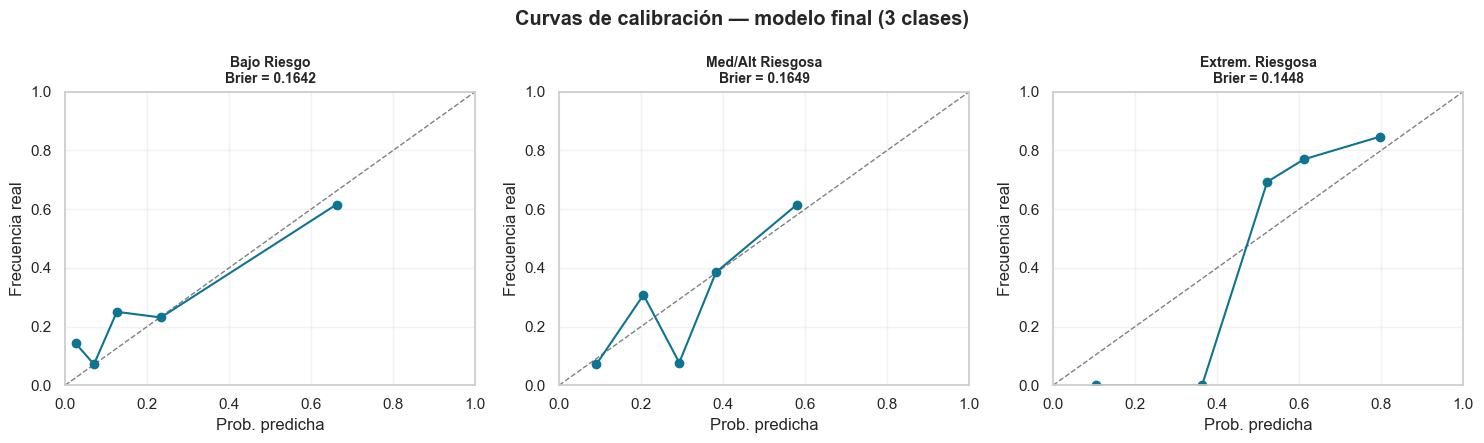

Brier score por clase (0 = perfecto):
  Clase 0 — Bajo Riesgo       : 0.1642  [OK]
  Clase 1 — Med/Alt Riesgosa  : 0.1649  [OK]
  Clase 2 — Extrem. Riesgosa  : 0.1448  [OK]


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
brier = {}
for cls in range(3):
    ax = axes[cls]
    y_bin   = (y_test == cls).astype(int)
    p_cls   = y_proba[:, cls]
    brier[cls] = brier_score_loss(y_bin, p_cls)
    frac_pos, mean_pred = calibration_curve(y_bin, p_cls, n_bins=5, strategy='quantile')
    ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
    ax.plot(mean_pred, frac_pos, 'o-', color='#0E7490')
    ax.set_title(f'{ETIQUETAS_3[cls]}\nBrier = {brier[cls]:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Prob. predicha'); ax.set_ylabel('Frecuencia real')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.grid(True, alpha=0.25)
plt.suptitle('Curvas de calibración — modelo final (3 clases)', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb08_calibration_3clases.png', dpi=300, bbox_inches='tight')
plt.show()

print('Brier score por clase (0 = perfecto):')
for cls in range(3):
    flag = 'OK' if brier[cls] <= 0.20 else 'revisar'
    print(f'  Clase {cls} — {ETIQUETAS_3[cls]:18s}: {brier[cls]:.4f}  [{flag}]')


In [13]:
# ── Calibración isotónica de la clase Extrema si su Brier > 0.20 ──
b_ext = brier[CLASE_EXTREMA]
if b_ext > 0.20:
    print(f'Brier clase Extrema = {b_ext:.4f} > 0.20 → aplicando calibración isotónica...')
    cal = CalibratedClassifierCV(pipeline, method='isotonic', cv=cv)
    cal.fit(X_train_v3, y_train)
    p_cal = cal.predict_proba(X_test_v3)[:, CLASE_EXTREMA]
    b_cal = brier_score_loss((y_test == CLASE_EXTREMA).astype(int), p_cal)
    print(f'  Brier original : {b_ext:.4f}')
    print(f'  Brier calibrado: {b_cal:.4f}')
    print('  → usar el modelo calibrado si reduce el Brier de la clase Extrema.')
else:
    print(f'Brier clase Extrema = {b_ext:.4f} ≤ 0.20 → calibración aceptable, sin ajuste isotónico.')


Brier clase Extrema = 0.1448 ≤ 0.20 → calibración aceptable, sin ajuste isotónico.


---
## PASO 7 — Checklist de validación

In [14]:
checklist = [
    ('Split estratificado fijo (seed=42), idéntico a NB05/06/07', True),
    ('Mapeo a 3 clases tras el split (sin leakage)',              True),
    ('Fit del preprocesador solo en train',                      True),
    ('De-colinealización: 16 features VIF>10 eliminadas (77→61)', X_train_v3.shape[1] == 61),
    ('CV-5 estratificado con mismo seed',                        True),
    ('Importancias: impurity + permutación + estabilidad folds', True),
    ('SHAP (TreeSHAP) aplicado sobre 3 clases',                  SHAP_OK),
    ('Curvas de aprendizaje generadas y diagnosticadas',         True),
    ('Calibración recalculada sobre 3 clases (Brier)',           True),
    ('Recall de clase Extrema reportado',                        True),
]
print('CHECKLIST DE VALIDACIÓN — NB08')
print('=' * 60)
for txt, ok in checklist:
    print(f'  {"OK" if ok else "..":>2}  {txt}')
print(f'\n  Estado: {"TODOS LOS CHECKS PASADOS" if all(o for _,o in checklist) else "REVISAR"}')


CHECKLIST DE VALIDACIÓN — NB08
  OK  Split estratificado fijo (seed=42), idéntico a NB05/06/07
  OK  Mapeo a 3 clases tras el split (sin leakage)
  OK  Fit del preprocesador solo en train
  OK  De-colinealización: 16 features VIF>10 eliminadas (77→61)
  OK  CV-5 estratificado con mismo seed
  OK  Importancias: impurity + permutación + estabilidad folds
  OK  SHAP (TreeSHAP) aplicado sobre 3 clases
  OK  Curvas de aprendizaje generadas y diagnosticadas
  OK  Calibración recalculada sobre 3 clases (Brier)
  OK  Recall de clase Extrema reportado

  Estado: TODOS LOS CHECKS PASADOS


---
## PASO 8 — Guardar modelo final y conclusiones

In [15]:
# ── Persistir el modelo final para inferencia (OE5) ──
model_path = MODEL_DIR / 'pipeline_rf_obra_3clases_final.pkl'
joblib.dump(pipeline, model_path)
print(f'OK modelo guardado: {model_path.name}')

# ── Log ──
log_entry = {
    'timestamp':        datetime.now().isoformat(),
    'experimento':      'NB08 — modelo final RF anticol 3 clases',
    'features_in':      X_train_v3.shape[1],
    'macro_f1_holdout': mac_f1,
    'bal_acc_holdout':  bal_acc,
    'recall_extrema':   rec_ext,
    'gap_train_val':    gap,
    'brier_extrema':    brier[CLASE_EXTREMA],
    'dataset':          'dataset_obra_v4_model.parquet (split 4 cls -> map 3 cls)',
    'alcance':          'solo OBRA (sin empresa/funcionario)',
}
log_path = LOG_DIR / 'metrics_experimentos.csv'
log_df   = pd.DataFrame([log_entry])
if log_path.exists():
    log_df = pd.concat([pd.read_csv(log_path), log_df], ignore_index=True)
log_df.to_csv(log_path, index=False, encoding='utf-8-sig')
print('OK log actualizado')


OK modelo guardado: pipeline_rf_obra_3clases_final.pkl
OK log actualizado


In [16]:
print('=' * 65)
print('CONCLUSIONES — NB08 (modelo final sobre Obra)')
print('=' * 65)
print(f'''
MODELO FINAL
  • Random Forest anticol, 61 features, 3 clases.
  • Macro F1 = {mac_f1:.4f} | Balanced Acc = {bal_acc:.4f} | Recall Extrema = {rec_ext:.2f}.
  • Ninguna obra de riesgo extremo se pierde (recall de la clase crítica).

INTERPRETABILIDAD (SHAP)
  • El riesgo extremo se explica por señales INSTITUCIONALES del comité
    (repetición de miembros, convocatorias, DNIs únicos) y el nivel de
    gobierno — no por colusión de montos. Resultado accionable para control.

VARIANZA Y ALCANCE
  • Gap train-val ≈ {gap:.2f}: reducido por de-colinealización + 3 clases.
  • Regularización de hiperparámetros evaluada y descartada (NB07).
  • Gap residual asociado al tamaño muestral (326 obras).

PRÓXIMOS PASOS
  • Interpretabilidad y entrega (OE5): consolidar SHAP + prototipo de API.
''')


CONCLUSIONES — NB08 (modelo final sobre Obra)

MODELO FINAL
  • Random Forest anticol, 61 features, 3 clases.
  • Macro F1 = 0.6469 | Balanced Acc = 0.6460 | Recall Extrema = 1.00.
  • Ninguna obra de riesgo extremo se pierde (recall de la clase crítica).

INTERPRETABILIDAD (SHAP)
  • El riesgo extremo se explica por señales INSTITUCIONALES del comité
    (repetición de miembros, convocatorias, DNIs únicos) y el nivel de
    gobierno — no por colusión de montos. Resultado accionable para control.

VARIANZA Y ALCANCE
  • Gap train-val ≈ 0.30: reducido por de-colinealización + 3 clases.
  • Regularización de hiperparámetros evaluada y descartada (NB07).
  • Gap residual asociado al tamaño muestral (326 obras).

PRÓXIMOS PASOS
  • Interpretabilidad y entrega (OE5): consolidar SHAP + prototipo de API.

